In [5]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Sample dataset
data = {
    'text': [
        'I love machine learning',
        'Python is amazing',
        'I hate bugs',
        'Machine learning is powerful',
        'Debugging is frustrating',
        'I enjoy coding',
        'Errors make me angry',
        'Programming is fun',
        'I dislike slow computers',
        'AI is fascinating'
    ],
    'label': [1, 1, 0, 1, 0, 1, 0, 1, 0, 1]
}

# Create a DataFrame
df = pd.DataFrame(data)

X = df['text']
y = df['label']

vectorizer = CountVectorizer()
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.3, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, zero_division=0))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset from online source (no local file needed)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

# Convert Month column to datetime
df['Month'] = pd.to_datetime(df['Month'])

# Set Month as index
df.set_index('Month', inplace=True)

# Rename column
df.rename(columns={'Passengers': 'y'}, inplace=True)

# Display first rows
print(df.head())

              y
Month          
1949-01-01  112
1949-02-01  118
1949-03-01  132
1949-04-01  129
1949-05-01  121


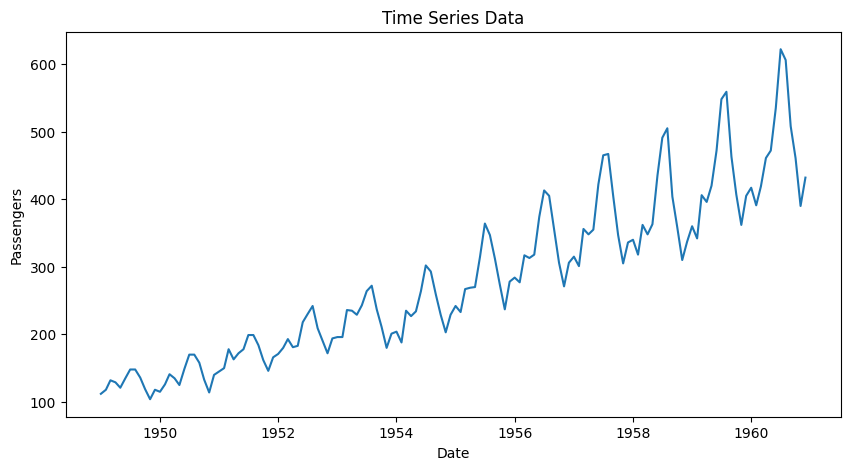

In [9]:
plt.figure(figsize=(10,5))
plt.plot(df['y'])
plt.title("Time Series Data")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.show()

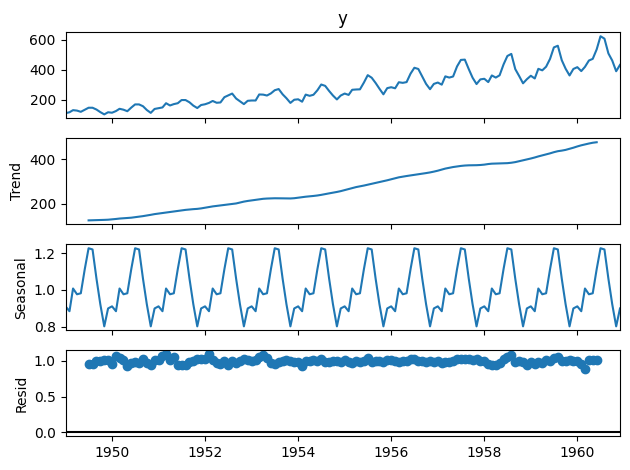

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose = seasonal_decompose(df['y'], model='multiplicative')

decompose.plot()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


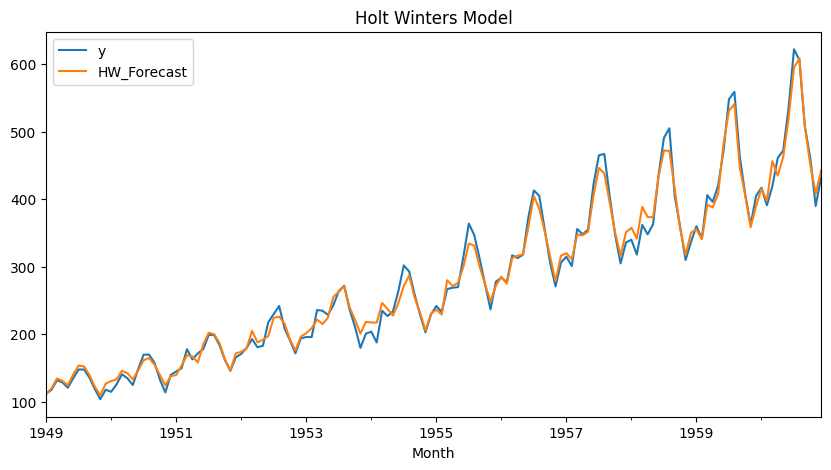

In [11]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
        df['y'],
        trend='add',
        seasonal='add',
        seasonal_periods=12
        )

fit = model.fit()

df['HW_Forecast'] = fit.fittedvalues

df[['y','HW_Forecast']].plot(figsize=(10,5))
plt.title("Holt Winters Model")
plt.show()